# Case Study: GitLab Sentiment

This case notebook follows a short case-study flow:
1. construct weighted daily sentiment for GitLab community data
2. define the comparison and dashboard visualizations
3. generate the GitLab case outputs
4. inspect the comparison and individual charts
            


## 1. Define the Weighted Sentiment Construction

This section adapts the weighting logic to a single-company case study.
            


In [1]:
import pandas as pd
import numpy as np
from datetime import datetime

def calculate_weighted_sentiment(df, company_name):
    """
    Calculate weighted sentiment scores for a company's Reddit data
    
    Parameters:
    df: DataFrame with Reddit data for one company
    company_name: String name of the company
    
    Returns:
    DataFrame with daily weighted sentiment and moving averages
    """
    
    # Create a copy to avoid modifying original data
    data = df.copy()
    
    # Convert created_utc to datetime (handle both string and numeric formats)
    if data['created_utc'].dtype == 'object':
        # If it's already a string datetime, convert directly
        data['created_date'] = pd.to_datetime(data['created_utc'])
    else:
        # If it's a Unix timestamp, convert with unit='s'
        data['created_date'] = pd.to_datetime(data['created_utc'], unit='s')
    
    if data['author_created_utc'].dtype == 'object':
        # If it's already a string datetime, convert directly
        data['author_created_date'] = pd.to_datetime(data['author_created_utc'])
    else:
        # If it's a Unix timestamp, convert with unit='s'
        data['author_created_date'] = pd.to_datetime(data['author_created_utc'], unit='s')
    
    # Calculate account age at time of posting (in days)
    data['account_age_days'] = (data['created_date'] - data['author_created_date']).dt.days
    
    # Handle negative account ages (data quality issues)
    data['account_age_days'] = data['account_age_days'].clip(lower=0)
    
    # Calculate total karma
    data['total_karma'] = data['author_link_karma'] + data['author_comment_karma']
    
    # Create weighting factors
    
    # 1. Content Type Weight (posts generally more visible than comments)
    data['type_weight'] = data['type'].map({
        'post': 1.5,
        'comment': 1.0
    }).fillna(1.0)
    
    # 2. Upvotes Weight (logarithmic scaling to prevent extreme outliers)
    # Add 1 to handle 0 upvotes, then log transform
    data['upvotes_weight'] = np.log1p(data['upvotes'].clip(lower=0))
    # Normalize to 0.5-2.0 range
    upvotes_min = data['upvotes_weight'].min()
    upvotes_max = data['upvotes_weight'].max()
    if upvotes_max > upvotes_min:
        data['upvotes_weight'] = 0.5 + 1.5 * (data['upvotes_weight'] - upvotes_min) / (upvotes_max - upvotes_min)
    else:
        data['upvotes_weight'] = 1.0
    
    # 3. Account Age Weight (more established accounts get higher weight)
    # Sigmoid function to cap the benefit of very old accounts
    data['age_weight'] = 1 / (1 + np.exp(-(data['account_age_days'] - 365) / 365))
    # Scale to 0.5-1.5 range
    data['age_weight'] = 0.5 + data['age_weight']
    
    # 4. Karma Weight (users with higher karma get slightly more weight)
    # Log transform and normalize
    data['karma_weight'] = np.log1p(data['total_karma'].clip(lower=0))
    karma_min = data['karma_weight'].min()
    karma_max = data['karma_weight'].max()
    if karma_max > karma_min:
        data['karma_weight'] = 0.8 + 0.4 * (data['karma_weight'] - karma_min) / (karma_max - karma_min)
    else:
        data['karma_weight'] = 1.0
    
    # 5. Word Count Weight (longer posts/comments get slightly more weight)
    data['length_weight'] = np.log1p(data['word_count'].clip(lower=1))
    length_min = data['length_weight'].min()
    length_max = data['length_weight'].max()
    if length_max > length_min:
        data['length_weight'] = 0.9 + 0.2 * (data['length_weight'] - length_min) / (length_max - length_min)
    else:
        data['length_weight'] = 1.0
    
    # 6. Subreddit Weight (assign weights based on subreddit relevance)
    # Higher weights for more tech-focused subreddits
    high_relevance_subs = ['programming', 'webdev', 'softwaredevelopment', 'softwareengineering', 
                          'devops', 'git', 'gitlab', 'github', 'bitbucket', 'cicd', 'jenkins']
    medium_relevance_subs = ['technology', 'sysadmin', 'cscareerquestions', 'ITCareerQuestions']
    
    def get_subreddit_weight(subreddit):
        if subreddit.lower() in high_relevance_subs:
            return 1.2
        elif subreddit.lower() in medium_relevance_subs:
            return 1.1
        else:
            return 1.0
    
    data['subreddit_weight'] = data['subreddit'].apply(get_subreddit_weight)
    
    # Calculate overall weight as product of all individual weights
    data['overall_weight'] = (data['type_weight'] * 
                             data['upvotes_weight'] * 
                             data['age_weight'] * 
                             data['karma_weight'] * 
                             data['length_weight'] * 
                             data['subreddit_weight'])
    
    # Calculate weighted sentiment scores
    data['weighted_positive'] = data['sentiment_positive'] * data['overall_weight']
    data['weighted_negative'] = data['sentiment_negative'] * data['overall_weight']
    data['weighted_neutral'] = data['sentiment_neutral'] * data['overall_weight']
    data['weighted_compound'] = data['sentiment_compound'] * data['overall_weight']
    
    # Group by date and calculate daily aggregates
    daily_sentiment = data.groupby(data['created_date'].dt.date).agg({
        'weighted_positive': 'sum',
        'weighted_negative': 'sum',
        'weighted_neutral': 'sum',
        'weighted_compound': 'sum',
        'overall_weight': 'sum',
        'id': 'count'  # Number of posts/comments per day
    }).reset_index()
    
    # Rename columns for clarity
    daily_sentiment.columns = ['date', 'total_weighted_positive', 'total_weighted_negative', 
                              'total_weighted_neutral', 'total_weighted_compound', 
                              'total_weight', 'post_count']
    
    # Calculate normalized daily sentiment (weighted average)
    daily_sentiment['daily_weighted_sentiment_positive'] = (
        daily_sentiment['total_weighted_positive'] / daily_sentiment['total_weight']
    ).fillna(0)
    
    daily_sentiment['daily_weighted_sentiment_negative'] = (
        daily_sentiment['total_weighted_negative'] / daily_sentiment['total_weight']
    ).fillna(0)
    
    daily_sentiment['daily_weighted_sentiment_neutral'] = (
        daily_sentiment['total_weighted_neutral'] / daily_sentiment['total_weight']
    ).fillna(0)
    
    daily_sentiment['daily_weighted_sentiment_compound'] = (
        daily_sentiment['total_weighted_compound'] / daily_sentiment['total_weight']
    ).fillna(0)
    
    # Sort by date
    daily_sentiment = daily_sentiment.sort_values('date').reset_index(drop=True)
    
    # Calculate Simple Moving Averages (SMA) for compound sentiment
    sentiment_col = 'daily_weighted_sentiment_compound'
    
    daily_sentiment['sma_7'] = daily_sentiment[sentiment_col].rolling(window=7, min_periods=1).mean()
    daily_sentiment['sma_14'] = daily_sentiment[sentiment_col].rolling(window=14, min_periods=1).mean()
    daily_sentiment['sma_30'] = daily_sentiment[sentiment_col].rolling(window=30, min_periods=1).mean()
    daily_sentiment['sma_50'] = daily_sentiment[sentiment_col].rolling(window=50, min_periods=1).mean()
    daily_sentiment['sma_100'] = daily_sentiment[sentiment_col].rolling(window=100, min_periods=1).mean()
    daily_sentiment['sma_250'] = daily_sentiment[sentiment_col].rolling(window=250, min_periods=1).mean()
    
    # Select final columns for output
    result = daily_sentiment[[
        'date',
        'daily_weighted_sentiment_compound',
        'daily_weighted_sentiment_positive',
        'daily_weighted_sentiment_negative', 
        'daily_weighted_sentiment_neutral',
        'sma_7',
        'sma_14',
        'sma_30',
        'sma_50',
        'sma_100',
        'sma_250',
        'post_count',
        'total_weight'
    ]].copy()
    
    # Rename for clarity
    result.columns = [
        'date',
        'daily_weighted_sentiment',
        'daily_weighted_positive',
        'daily_weighted_negative',
        'daily_weighted_neutral', 
        'sma_7',
        'sma_14',
        'sma_30',
        'sma_50',
        'sma_100',
        'sma_250',
        'daily_post_count',
        'daily_total_weight'
    ]
    
    return result

def analyze_company_sentiment(df, company_name):
    """
    Wrapper function to analyze sentiment for a single company
    
    Usage:
    gitlab_results = analyze_company_sentiment(gitlab_df, "GitLab")
    github_results = analyze_company_sentiment(github_df, "GitHub")
    """
    
    print(f"Analyzing sentiment for {company_name}...")
    print(f"Total records: {len(df)}")
    
    # Handle datetime conversion for display
    if df['created_utc'].dtype == 'object':
        date_min = pd.to_datetime(df['created_utc']).min()
        date_max = pd.to_datetime(df['created_utc']).max()
    else:
        date_min = pd.to_datetime(df['created_utc'], unit='s').min()
        date_max = pd.to_datetime(df['created_utc'], unit='s').max()
    
    print(f"Date range: {date_min} to {date_max}")
    
    results = calculate_weighted_sentiment(df, company_name)
    
    print(f"Daily sentiment records: {len(results)}")
    print(f"Average daily weighted sentiment: {results['daily_weighted_sentiment'].mean():.4f}")
    print(f"Latest SMA values:")
    print(f"  7-day: {results['sma_7'].iloc[-1]:.4f}")
    print(f"  30-day: {results['sma_30'].iloc[-1]:.4f}")
    print(f"  100-day: {results['sma_100'].iloc[-1]:.4f}")
    print("-" * 50)
    
    return results

# Example usage:
"""
# Load your data
gitlab_df = pd.read_csv('gitlab_data.csv')
github_df = pd.read_csv('github_data.csv')
bitbucket_df = pd.read_csv('bitbucket_df.csv')
jenkins_df = pd.read_csv('jenkins_data.csv')
azure_devops_df = pd.read_csv('azure_devops_data.csv')

# Analyze each company
gitlab_sentiment = analyze_company_sentiment(gitlab_df, "GitLab")
github_sentiment = analyze_company_sentiment(github_df, "GitHub")
bitbucket_sentiment = analyze_company_sentiment(bitbucket_df, "Bitbucket")
jenkins_sentiment = analyze_company_sentiment(jenkins_df, "Jenkins")
azure_sentiment = analyze_company_sentiment(azure_devops_df, "Azure DevOps")

# Display results
print("GitLab Sentiment Analysis:")
print(gitlab_sentiment.head(10))
print(gitlab_sentiment.tail(10))
"""

'\n# Load your data\ngitlab_df = pd.read_csv(\'gitlab_data.csv\')\ngithub_df = pd.read_csv(\'github_data.csv\')\nbitbucket_df = pd.read_csv(\'bitbucket_df.csv\')\njenkins_df = pd.read_csv(\'jenkins_data.csv\')\nazure_devops_df = pd.read_csv(\'azure_devops_data.csv\')\n\n# Analyze each company\ngitlab_sentiment = analyze_company_sentiment(gitlab_df, "GitLab")\ngithub_sentiment = analyze_company_sentiment(github_df, "GitHub")\nbitbucket_sentiment = analyze_company_sentiment(bitbucket_df, "Bitbucket")\njenkins_sentiment = analyze_company_sentiment(jenkins_df, "Jenkins")\nazure_sentiment = analyze_company_sentiment(azure_devops_df, "Azure DevOps")\n\n# Display results\nprint("GitLab Sentiment Analysis:")\nprint(gitlab_sentiment.head(10))\nprint(gitlab_sentiment.tail(10))\n'

## 2. Define the Visualization Helpers

These helper functions create both the single-company dashboard and the comparison charts.
            


In [3]:
import pandas as pd
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots
import numpy as np

def plot_individual_company_sentiment(sentiment_df, company_name, show_components=True):
    """
    Create comprehensive sentiment chart for a single company
    
    Parameters:
    sentiment_df: DataFrame from calculate_weighted_sentiment function
    company_name: String name of the company
    show_components: Boolean to show positive/negative components
    """
    
    fig = make_subplots(
        rows=2, cols=1,
        subplot_titles=[f'{company_name} - Daily Weighted Sentiment with Moving Averages',
                       f'{company_name} - Sentiment Components & Post Volume'],
        vertical_spacing=0.15,
        row_heights=[0.7, 0.3]
    )
    
    # Main sentiment chart (top subplot)
    # Daily sentiment line
    fig.add_trace(
        go.Scatter(
            x=sentiment_df['date'],
            y=sentiment_df['daily_weighted_sentiment'],
            mode='lines',
            name='Daily Sentiment',
            line=dict(color='lightgray', width=1),
            opacity=0.7
        ),
        row=1, col=1
    )
    
    # Moving averages
    colors = {
        'sma_7': '#FF6B6B',
        'sma_14': '#4ECDC4', 
        'sma_30': '#45B7D1',
        'sma_50': '#96CEB4',
        'sma_100': '#FECA57',
        'sma_250': '#FF9FF3'
    }
    
    line_widths = {
        'sma_7': 2,
        'sma_14': 2,
        'sma_30': 3,
        'sma_50': 3,
        'sma_100': 2,
        'sma_250': 2
    }
    
    for sma_col in ['sma_7', 'sma_14', 'sma_30', 'sma_50', 'sma_100', 'sma_250']:
        if sma_col in sentiment_df.columns:
            fig.add_trace(
                go.Scatter(
                    x=sentiment_df['date'],
                    y=sentiment_df[sma_col],
                    mode='lines',
                    name=f'{sma_col.upper().replace("_", " ")}',
                    line=dict(color=colors[sma_col], width=line_widths[sma_col])
                ),
                row=1, col=1
            )
    
    # Add horizontal line at y=0
    fig.add_hline(y=0, line_dash="dash", line_color="gray", opacity=0.5, row=1, col=1)
    
    if show_components:
        # Bottom subplot - sentiment components and volume
        fig.add_trace(
            go.Scatter(
                x=sentiment_df['date'],
                y=sentiment_df['daily_weighted_positive'],
                mode='lines',
                name='Positive',
                line=dict(color='green', width=2),
                fill='tonexty'
            ),
            row=2, col=1
        )
        
        fig.add_trace(
            go.Scatter(
                x=sentiment_df['date'],
                y=sentiment_df['daily_weighted_negative'],
                mode='lines',
                name='Negative',
                line=dict(color='red', width=2),
                fill='tozeroy'
            ),
            row=2, col=1
        )
        
        # Add post count as secondary y-axis
        fig.add_trace(
            go.Bar(
                x=sentiment_df['date'],
                y=sentiment_df['daily_post_count'],
                name='Daily Posts',
                opacity=0.3,
                yaxis='y3',
                marker_color='blue'
            ),
            row=2, col=1
        )
    
    # Update layout
    fig.update_layout(
        title=f'{company_name} Sentiment Analysis Dashboard',
        height=800,
        showlegend=True,
        hovermode='x unified',
        template='plotly_white'
    )
    
    # Update x-axes
    fig.update_xaxes(title_text="Date", row=2, col=1)
    
    # Update y-axes
    fig.update_yaxes(title_text="Weighted Sentiment Score", row=1, col=1)
    fig.update_yaxes(title_text="Sentiment Components", row=2, col=1)
    
    # Add secondary y-axis for post count
    if show_components:
        fig.update_layout(
            yaxis3=dict(
                title="Daily Post Count",
                overlaying="y2",
                side="right"
            )
        )
    
    return fig

def plot_company_comparison(sentiment_data_dict, sma_period='sma_30', title_suffix=""):
    """
    Compare multiple companies on a single chart
    
    Parameters:
    sentiment_data_dict: Dictionary with company names as keys and sentiment DataFrames as values
                        e.g., {'GitLab': gitlab_sentiment, 'GitHub': github_sentiment}
    sma_period: String indicating which SMA to compare ('sma_7', 'sma_30', 'sma_50', etc.)
    title_suffix: Additional text for chart title
    """
    
    fig = go.Figure()
    
    colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4', '#FECA57', '#FF9FF3', '#A8E6CF']
    
    for i, (company_name, sentiment_df) in enumerate(sentiment_data_dict.items()):
        color = colors[i % len(colors)]
        
        # Add the selected SMA line
        fig.add_trace(
            go.Scatter(
                x=sentiment_df['date'],
                y=sentiment_df[sma_period],
                mode='lines',
                name=f'{company_name}',
                line=dict(color=color, width=3),
                hovertemplate='<b>' + company_name + '</b><br>' +
                             'Date: %{x}<br>' +
                             sma_period.upper() + ': %{y:.4f}<br>' +
                             '<extra></extra>'
            )
        )
    
    # Add horizontal line at y=0
    fig.add_hline(y=0, line_dash="dash", line_color="gray", opacity=0.5)
    
    # Update layout
    sma_label = sma_period.replace('_', '-').upper()
    fig.update_layout(
        title=f'Company Comparison: {sma_label} Moving Average {title_suffix}',
        xaxis_title='Date',
        yaxis_title=f'Weighted Sentiment Score ({sma_label})',
        height=600,
        hovermode='x unified',
        template='plotly_white',
        legend=dict(
            yanchor="top",
            y=0.99,
            xanchor="left",
            x=0.01
        )
    )
    
    return fig

def plot_multiple_sma_comparison(sentiment_data_dict, sma_periods=['sma_7', 'sma_30', 'sma_100']):
    """
    Create subplot comparison of multiple SMAs for all companies
    
    Parameters:
    sentiment_data_dict: Dictionary with company names as keys and sentiment DataFrames as values
    sma_periods: List of SMA periods to compare
    """
    
    n_periods = len(sma_periods)
    fig = make_subplots(
        rows=n_periods, cols=1,
        subplot_titles=[f'{sma.replace("_", "-").upper()} Comparison' for sma in sma_periods],
        vertical_spacing=0.08
    )
    
    colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4', '#FECA57', '#FF9FF3', '#A8E6CF']
    
    for row, sma_period in enumerate(sma_periods, 1):
        for i, (company_name, sentiment_df) in enumerate(sentiment_data_dict.items()):
            color = colors[i % len(colors)]
            
            showlegend = (row == 1)  # Only show legend for first subplot
            
            fig.add_trace(
                go.Scatter(
                    x=sentiment_df['date'],
                    y=sentiment_df[sma_period],
                    mode='lines',
                    name=f'{company_name}',
                    line=dict(color=color, width=2),
                    showlegend=showlegend,
                    hovertemplate='<b>' + company_name + '</b><br>' +
                                 'Date: %{x}<br>' +
                                 sma_period.upper() + ': %{y:.4f}<br>' +
                                 '<extra></extra>'
                ),
                row=row, col=1
            )
        
        # Add horizontal line at y=0 for each subplot
        fig.add_hline(y=0, line_dash="dash", line_color="gray", opacity=0.5, row=row, col=1)
    
    # Update layout
    fig.update_layout(
        title='Multi-Period SMA Comparison Across Companies',
        height=200 * n_periods + 100,
        hovermode='x unified',
        template='plotly_white'
    )
    
    # Update axes
    for i in range(1, n_periods + 1):
        fig.update_yaxes(title_text="Sentiment Score", row=i, col=1)
    
    fig.update_xaxes(title_text="Date", row=n_periods, col=1)
    
    return fig

def create_summary_stats_table(sentiment_data_dict):
    """
    Create a summary statistics table for all companies
    """
    
    summary_data = []
    
    for company_name, sentiment_df in sentiment_data_dict.items():
        # Calculate summary statistics
        stats = {
            'Company': company_name,
            'Avg_Sentiment': sentiment_df['daily_weighted_sentiment'].mean(),
            'Std_Sentiment': sentiment_df['daily_weighted_sentiment'].std(),
            'Min_Sentiment': sentiment_df['daily_weighted_sentiment'].min(),
            'Max_Sentiment': sentiment_df['daily_weighted_sentiment'].max(),
            'Latest_SMA7': sentiment_df['sma_7'].iloc[-1] if len(sentiment_df) > 0 else np.nan,
            'Latest_SMA30': sentiment_df['sma_30'].iloc[-1] if len(sentiment_df) > 0 else np.nan,
            'Latest_SMA100': sentiment_df['sma_100'].iloc[-1] if len(sentiment_df) > 0 else np.nan,
            'Total_Posts': sentiment_df['daily_post_count'].sum(),
            'Avg_Daily_Posts': sentiment_df['daily_post_count'].mean(),
            'Days_Analyzed': len(sentiment_df)
        }
        summary_data.append(stats)
    
    summary_df = pd.DataFrame(summary_data)
    
    # Round numerical columns
    numeric_cols = summary_df.select_dtypes(include=[np.number]).columns
    summary_df[numeric_cols] = summary_df[numeric_cols].round(4)
    
    return summary_df

# Example usage functions:
def create_all_charts(sentiment_data_dict):
    """
    Create all visualization charts at once
    
    Parameters:
    sentiment_data_dict: Dictionary like {'GitLab': gitlab_sentiment, 'GitHub': github_sentiment, ...}
    
    Returns:
    Dictionary of all created figures
    """
    
    charts = {}
    
    # Individual company charts
    for company_name, sentiment_df in sentiment_data_dict.items():
        charts[f'{company_name}_individual'] = plot_individual_company_sentiment(
            sentiment_df, company_name
        )
    
    # Comparison charts
    charts['sma7_comparison'] = plot_company_comparison(
        sentiment_data_dict, 'sma_7', '(Short-term Trend)'
    )
    
    charts['sma30_comparison'] = plot_company_comparison(
        sentiment_data_dict, 'sma_30', '(Medium-term Trend)'
    )
    
    charts['sma100_comparison'] = plot_company_comparison(
        sentiment_data_dict, 'sma_100', '(Long-term Trend)'
    )
    
    # Multi-period comparison
    charts['multi_sma_comparison'] = plot_multiple_sma_comparison(
        sentiment_data_dict, ['sma_7', 'sma_30', 'sma_100']
    )
    
    # Summary statistics
    charts['summary_stats'] = create_summary_stats_table(sentiment_data_dict)
    
    return charts


## 3. Load the GitLab Case Data and Calculate Daily Sentiment

The analysis below is currently run for GitLab, with the other company inputs left commented for optional comparison work.
            


In [23]:
# Load your data
gitlab_df = pd.read_csv('GTLB_Tech_Communities.csv')
# github_df = pd.read_csv('GitHub.csv')
# bitbucket_df = pd.read_csv('Bitbucket.csv')
# # jenkins_df = pd.read_csv('jenkins_data.csv')
# azure_devops_df = pd.read_csv('AzureDevOps.csv')

# Analyze each company
gitlab_sentiment = analyze_company_sentiment(gitlab_df, "GitLab")
# github_sentiment = analyze_company_sentiment(github_df, "GitHub")
# bitbucket_sentiment = analyze_company_sentiment(bitbucket_df, "Bitbucket")
# # jenkins_sentiment = analyze_company_sentiment(jenkins_df, "Jenkins")
# azure_sentiment = analyze_company_sentiment(azure_devops_df, "Azure DevOps")

# # Display results
# print("GitLab Sentiment Analysis:")
# print(gitlab_sentiment.head(10))
# print(gitlab_sentiment.tail(10))


Analyzing sentiment for GitLab...
Total records: 1739
Date range: 2015-07-24 12:39:21 to 2025-06-03 22:29:51
Daily sentiment records: 718
Average daily weighted sentiment: 0.5350
Latest SMA values:
  7-day: 0.6645
  30-day: 0.4223
  100-day: 0.5124
--------------------------------------------------


## 4. Generate and Review the Case Outputs

The first cell creates the comparison views and summary table, and the second shows the detailed GitLab chart.
            


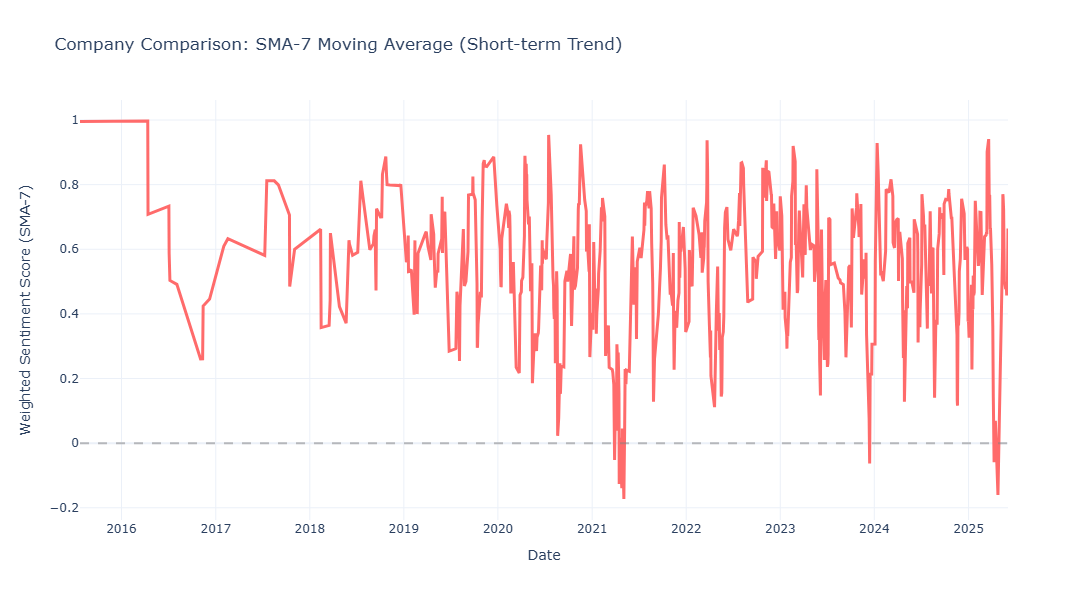

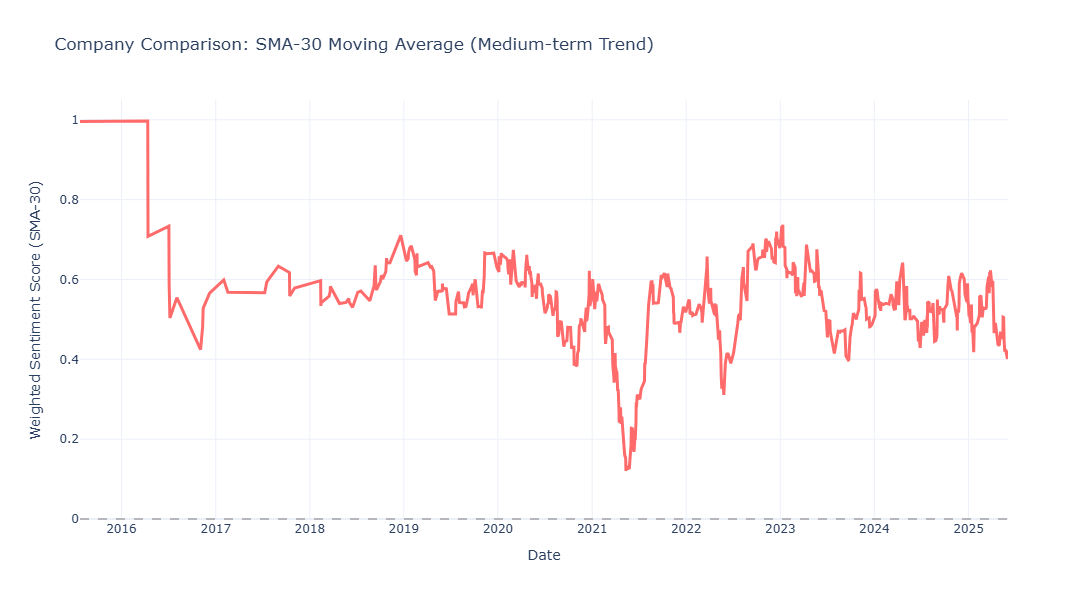

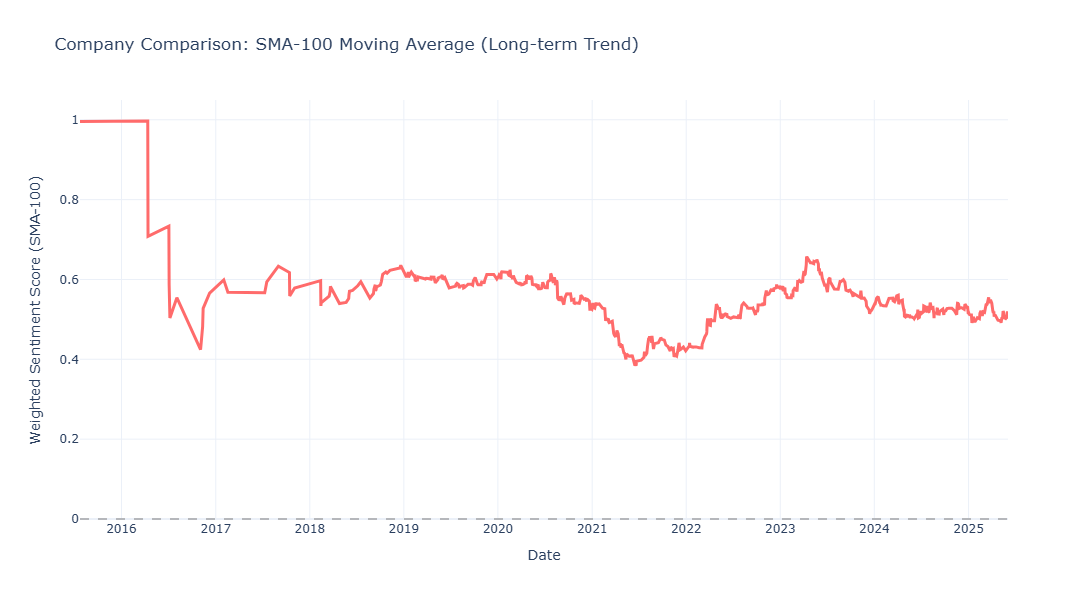

,Company,Avg_Sentiment,Std_Sentiment,Min_Sentiment,Max_Sentiment,Latest_SMA7,Latest_SMA30,Latest_SMA100,Total_Posts,Avg_Daily_Posts,Days_Analyzed
0,GitLab,0.535,0.5535,-0.9986,1.0,0.6645,0.4223,0.5124,1739,2.422,718


In [25]:
sentiment_results = {
    'GitLab': gitlab_sentiment,
    # 'GitHub': github_sentiment,
    # 'Bitbucket': bitbucket_sentiment,
    # 'Azure DevOps': azure_sentiment
}

# Create all charts
all_charts = create_all_charts(sentiment_results)

# Display individual charts
# all_charts['GitLab_individual'].show()
# all_charts['GitHub_individual'].show()

# Display comparison charts
all_charts['sma7_comparison'].show()
all_charts['sma30_comparison'].show()
all_charts['sma100_comparison'].show()
all_charts['summary_stats']

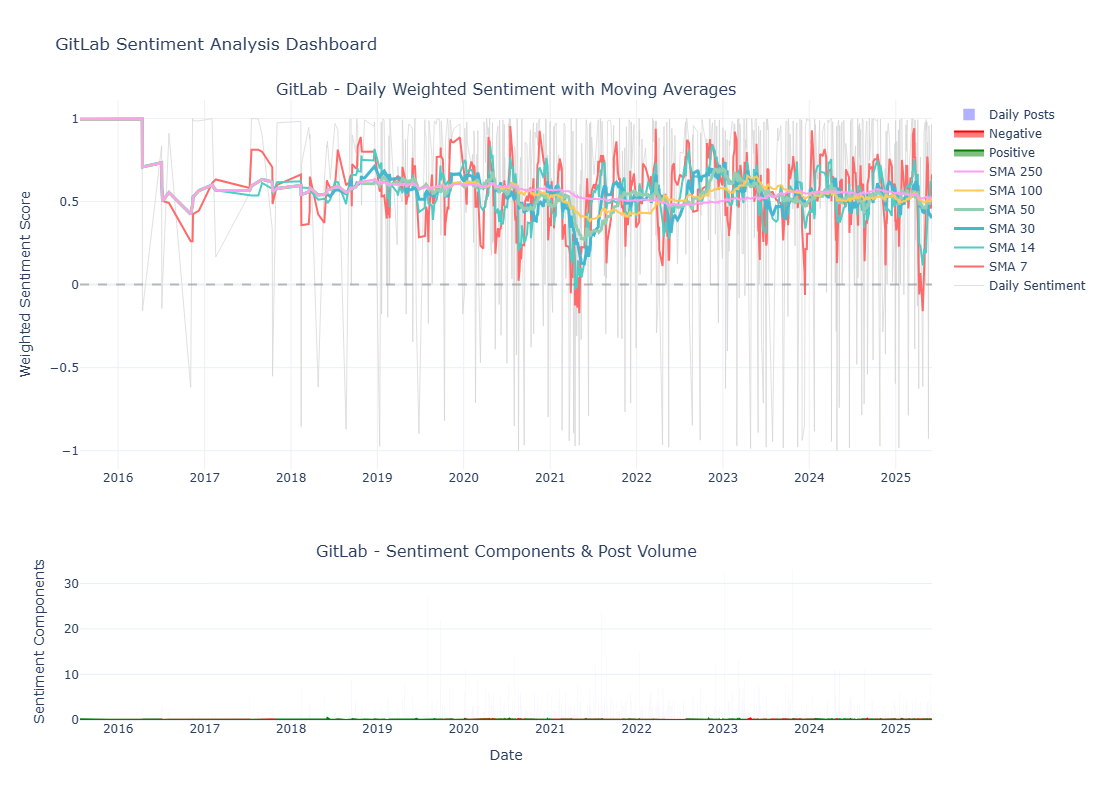

In [27]:
all_charts['GitLab_individual'].show()